The goal of this notebook is to analyse and aggregate the bureau table, combine it with the bureau_balance table, and use the derived information to enhance predictions in the application.

# Setup

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib

import matplotlib.pyplot as plt

from helpers import preprocessing, submissions, preprocessing, bureau_helper

from helpers.utils import stats_helper, plotting_helper, unsupervised_helper, aggregator_helper
from helpers.model_builders import bureau_preparation

from helpers.utils.cleaner_helper import plot_categorical_dist, plot_numeric_dist

from sklearn.preprocessing import StandardScaler
import hdbscan
import importlib


In [ ]:
bureau = preprocessing.load_pkl_to_preprocessor('bureau')
display(bureau.convert_all('category').info(show_counts=True))
bureau.data[['SK_ID_BUREAU', 'SK_ID_CURR']]=bureau.data[['SK_ID_BUREAU', 'SK_ID_CURR']].astype(str)
print(bureau.column_structure)
bureau_df = bureau.data

Loading tables: ['bureau.csv']
loaded bureau with shape (1716428, 17)
dict_keys(['credit_status', 'bureau_overdue', 'time_variables', 'bureau', 'bureau_balance', 'pos_cash_balance', 'balance_limits', 'drawings_payments', 'contract_installments', 'credit_card_balance', 'previous_application', 'installments_payments'])
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'SK_ID_BUREAU']
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'SK_ID_BUREAU']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype   
---  ------                  --------------    -----   
 0   SK_ID_CURR              1716428 non-null  object  
 1   SK_ID_BUREAU            1716428 non-null  int64   
 2   CREDIT_ACTIVE           1716428 non-null  category
 3   CREDIT_CURRENCY         1716428 non-null  category
 4   DAYS_CREDIT             1716428 non-null  int64   
 5   CREDIT_DAY_OVERDUE      17164

None

['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']


# EDA

### Bureau Description:
bureau.csv

* All client's previous credits provided by other financial institutions that were reported to Credit Bureau (for clients who have a loan in our sample).
* For every loan in our sample, there are as many rows as number of credits the client had in Credit Bureau before the application date.



#### unique applicants

The application train and test tables are 307511 and 48744 values, respectively. For a total of 356255

In [ ]:
print("Unique clients in bureau:", bureau_df["SK_ID_CURR"].unique().shape[0])
print(
    "Difference from application train and test:",
    bureau_df["SK_ID_CURR"].unique().shape[0] - 356255,
)

Unique clients in bureau: 305811
Difference from application train and test: -50444


A significant portion of applicants have no known history of previous loans within the bureau. NaN robust techniques or imputation will be required to make the information usable for further analysis.

Text(0, 0.5, 'Number of clients')

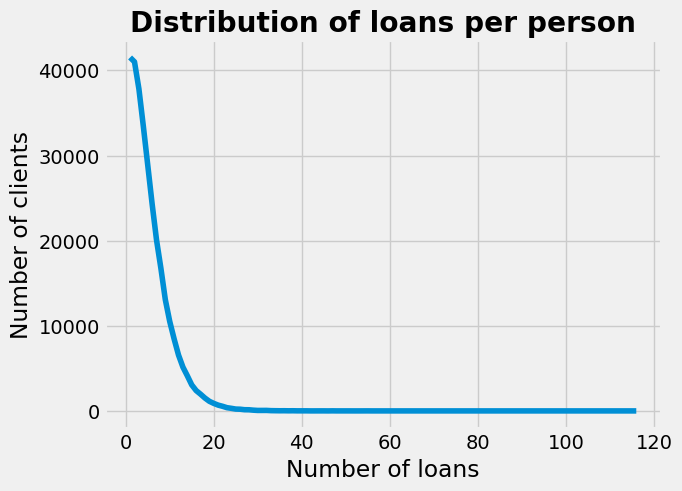

In [ ]:
loans_per_person = bureau_df.groupby("SK_ID_CURR").size().value_counts().reset_index()
loans_per_person.columns = ['loans', 'instances']
sns.lineplot(data=loans_per_person, x='loans', y= 'instances')
plt.title("Distribution of loans per person")
plt.xlabel("Number of loans")
plt.ylabel("Number of clients")

* Almost all individuals have had less than 20 loans.
* Loan distribution can be modelled as poisson distribution.
* More nuanced aggregation than mean or median is required.

### Variable correlation

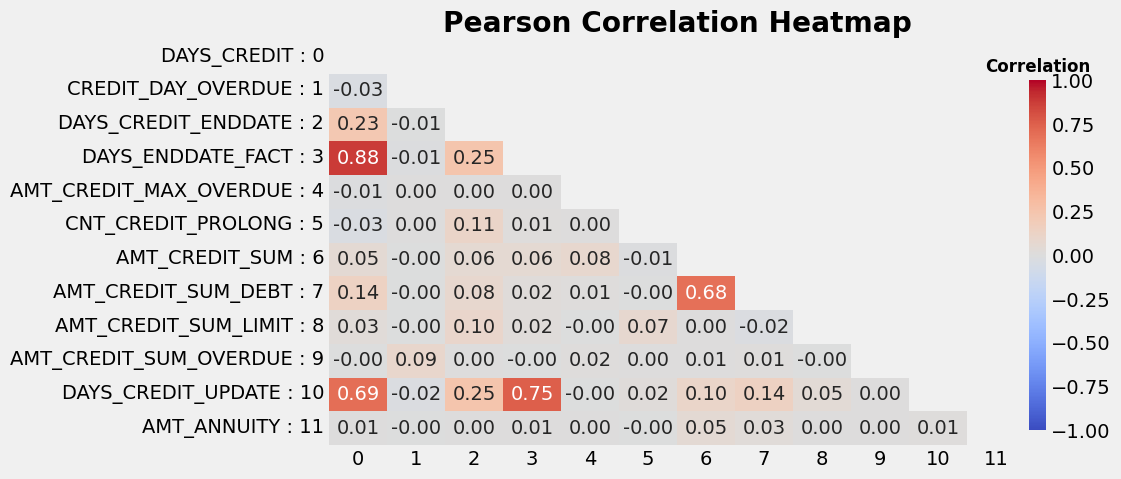

In [ ]:
plotting_helper.plot_corr_triangle(bureau_df, figsize=(10, 5), square=False, annot=True);

* Majority of variables are semi orthogonal:

The followign variables are involved in strong positive associations:
* `DAYS_CREDIT` - How many days before current application did client apply for Credit Bureau credit.
* `DAYS_CREDIT_ENDDATE` - Remaining duration of CB credit (in days) at the time of application in Home Credit.
* `DAYS_ENDDATE_FACT` - Days since CB credit ended at the time of application in Home Credit (only for closed credit).
* `DAYS_CREDIT_UPDATE` - How many days before loan application did last information about the Credit Bureau credit come.
* `AMT_CREDIT_SUM` - Current credit amount for the Credit Bureau credit.
* `AMT_CREDIT_SUM_DEPT` - Current debt on Credit Bureau credit.


# Unsupervised learning

## grouping (HDBSCAN)

In [ ]:
X = bureau_df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
X.describe()

,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
count,1.716428e+06,1.716428e+06,1.610875e+06,1.082775e+06,5.919400e+05,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06,1.716428e+06,1.716428e+06,4.896370e+05
mean,-1.142108e+03,8.181666e-01,5.105174e+02,-1.017437e+03,3.825418e+03,6.410406e-03,3.549946e+05,1.370851e+05,6.229515e+03,3.791276e+01,-5.937483e+02,1.571276e+04
std,7.951649e+02,3.654443e+01,4.994220e+03,7.140106e+02,2.060316e+05,9.622391e-02,1.149811e+06,6.774011e+05,4.503203e+04,5.937650e+03,7.207473e+02,3.258269e+05
min,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04,0.000000e+00
25%,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02,0.000000e+00
50%,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02,0.000000e+00
75%,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01,1.350000e+04
max,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,1.159872e+08,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02,1.184534e+08


* Extreme outliers exist  that will complicate unsupervised learning applications, since they are distance dependant 
Consequently, the outlier values are cut.

c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[-1  0  1]


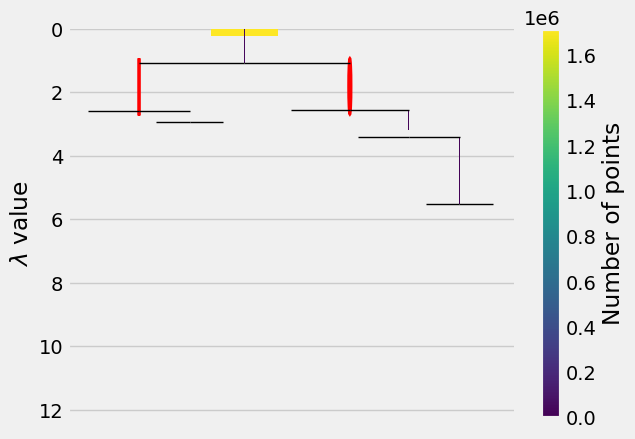

In [ ]:
X = bureau_df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')

X = stats_helper.clip_IQR_outliers(X, quantile=0.2, multiplier=2)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

clusterer = hdbscan.HDBSCAN(min_cluster_size=100)
labels= clusterer.fit_predict(X)
clusterer.condensed_tree_.plot(select_clusters=True)

print(np.unique(labels))

In [ ]:
X['group'] = labels.astype(str)
unsupervised_helper.plotly_3d_pca(X, hue_col='group')

Plotting 3D PCA with discarded NANs


* Values appear to separate into two parallel surfaces on the PCA axes, which confirms success of classification.


Corrected p-values for Wilcoxon test within clusters:


,p_value,1_median,0_median
DAYS_CREDIT,4.436825e-159,-10332.0,-14166.0
CREDIT_DAY_OVERDUE,1.000000e+00,0.0,0.0
DAYS_CREDIT_ENDDATE,1.159411e-69,-6756.0,-8712.0
DAYS_ENDDATE_FACT,4.128703e-51,-7296.0,-9048.0
AMT_CREDIT_MAX_OVERDUE,0.000000e+00,0.0,1.0
CNT_CREDIT_PROLONG,4.004795e-19,0.0,0.0
AMT_CREDIT_SUM,8.266503e-14,1.0,1.0
AMT_CREDIT_SUM_DEBT,5.318992e-04,0.0,0.0
AMT_CREDIT_SUM_LIMIT,2.711696e-04,0.0,0.0
AMT_CREDIT_SUM_OVERDUE,1.000000e+00,0.0,0.0


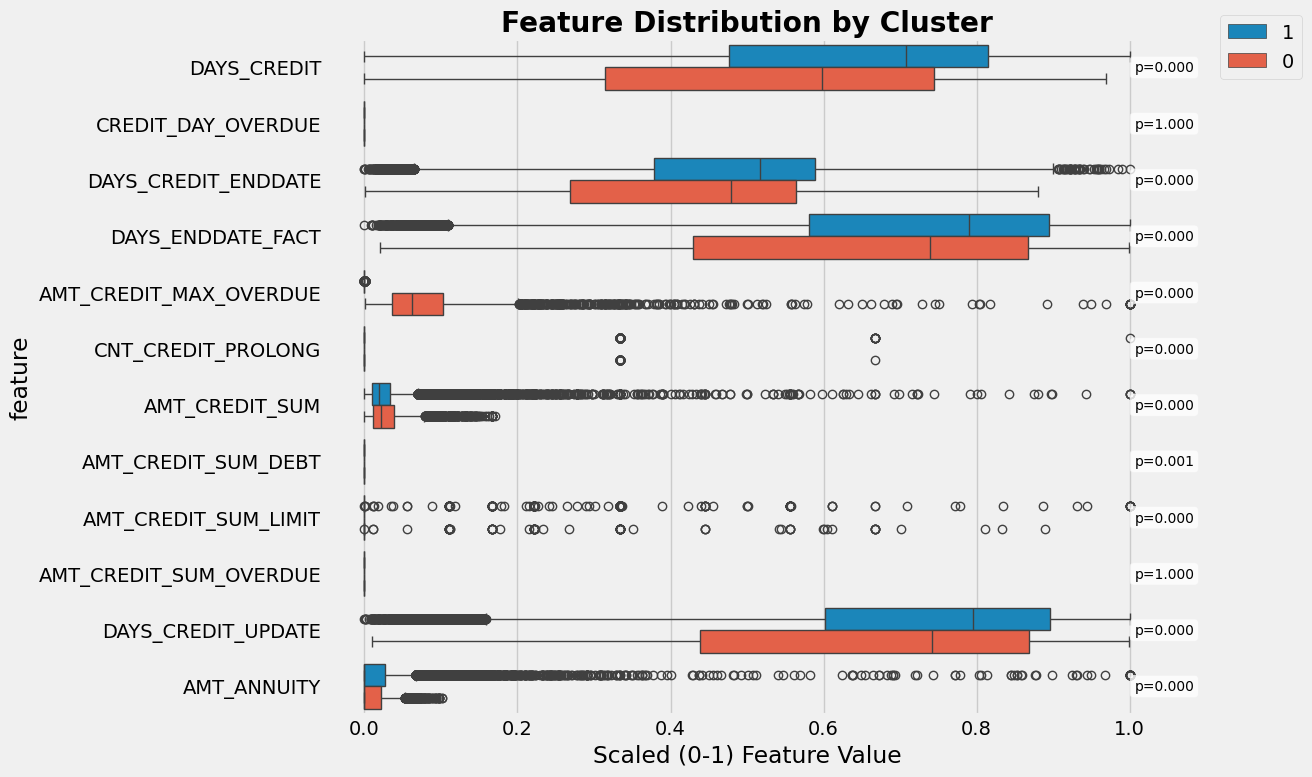

In [ ]:
stats_helper.plot_kruskal_results(
    data=bureau_df[bureau_df.index.isin(X.index)].assign(group=X['group']).loc[X['group']!='-1'],
    cluster_label_col='group',
    correction='Bonferroni'
)

* The two groups successfully separated 10/12 features.
* However, given the need of non-missing nan-values, they should not be able to provide good predictive power for Target variable.

# Data Aggregation and ML

## Splits and encoding 
Following columns provide key splits for classifying credit status.

In [ ]:
bureau_df.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


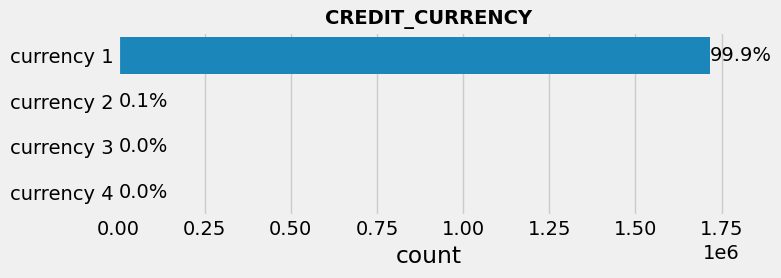

CREDIT_CURRENCY
currency 1    1715020
currency 2       1224
currency 3        174
currency 4         10
Name: count, dtype: int64

In [ ]:
plot_categorical_dist(bureau_df, "CREDIT_CURRENCY")

* Only currency one will be considered. Exchange rates and currencies are not provided and thus objective comparison is impossible possible.

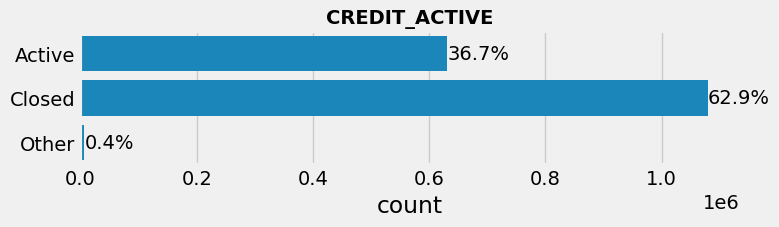

CREDIT_ACTIVE
Closed    1079273
Active     630607
Other        6548
Name: count, dtype: int64

In [ ]:
plot_categorical_dist(bureau_preparation.simplify_credit_active(bureau_df), "CREDIT_ACTIVE")

* Active, closed, and sold debts need to be considered separately. Someone who has took out but returned massive loans is much more reliable than someone actively owning money.
    * These will provide a basis for encoding.
* Bad dept will be considered identical to sold, since in both cases the bank decided not pursue it personally.

## Feature aggregation
Majority of credit metrics are related to amounts borrowed currency. **Summing for aggregation will be most representative**, since we are interested in whole borrowing history instead of the average loan.

In [ ]:
metrics_dict = {
    "CREDIT_ACTIVE": "count",
    **{col: ["min", "median", "max", "std", "sum"] for col in 
        bureau_df.select_dtypes(include=[np.number]).columns
    },
}

print("Metrics dictionary:", metrics_dict)


Metrics dictionary: {'CREDIT_ACTIVE': 'count', 'DAYS_CREDIT': ['min', 'median', 'max', 'std', 'sum'], 'CREDIT_DAY_OVERDUE': ['min', 'median', 'max', 'std', 'sum'], 'DAYS_CREDIT_ENDDATE': ['min', 'median', 'max', 'std', 'sum'], 'DAYS_ENDDATE_FACT': ['min', 'median', 'max', 'std', 'sum'], 'AMT_CREDIT_MAX_OVERDUE': ['min', 'median', 'max', 'std', 'sum'], 'CNT_CREDIT_PROLONG': ['min', 'median', 'max', 'std', 'sum'], 'AMT_CREDIT_SUM': ['min', 'median', 'max', 'std', 'sum'], 'AMT_CREDIT_SUM_DEBT': ['min', 'median', 'max', 'std', 'sum'], 'AMT_CREDIT_SUM_LIMIT': ['min', 'median', 'max', 'std', 'sum'], 'AMT_CREDIT_SUM_OVERDUE': ['min', 'median', 'max', 'std', 'sum'], 'DAYS_CREDIT_UPDATE': ['min', 'median', 'max', 'std', 'sum'], 'AMT_ANNUITY': ['min', 'median', 'max', 'std', 'sum']}


In [ ]:
bureau_df = bureau_preparation.choose_currency(bureau_preparation.simplify_credit_active(bureau_df))
bureau_df.head()

Filtering for currency: currency 1


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


A helper class is implemented for further readability. It performs all aforementioned actions and tricks.

In [ ]:
agg = aggregator_helper.RowAggregator(
    bureau_df, stack_columns=["SK_ID_CURR"], agg_dict=metrics_dict
)
agg_bureau = agg.get_df()
agg_bureau.head(5)

,SK_ID_CURR,count_CREDIT_ACTIVE,min_DAYS_CREDIT,median_DAYS_CREDIT,max_DAYS_CREDIT,std_DAYS_CREDIT,sum_DAYS_CREDIT,min_CREDIT_DAY_OVERDUE,median_CREDIT_DAY_OVERDUE,max_CREDIT_DAY_OVERDUE,...,min_DAYS_CREDIT_UPDATE,median_DAYS_CREDIT_UPDATE,max_DAYS_CREDIT_UPDATE,std_DAYS_CREDIT_UPDATE,sum_DAYS_CREDIT_UPDATE,min_AMT_ANNUITY,median_AMT_ANNUITY,max_AMT_ANNUITY,std_AMT_ANNUITY,sum_AMT_ANNUITY
0,100001,7,-1572,-857.0,-49,489.942514,-5145,0,0.0,0,...,-155,-155.0,-6,77.204120,-652,0.0,0.0,10822.5,4800.607529,24817.5
1,100002,8,-1437,-1042.5,-103,431.451040,-6992,0,0.0,0,...,-1185,-402.5,-7,518.522472,-3999,0.0,0.0,0.0,0.000000,0.0
2,100003,4,-2586,-1205.5,-606,909.826128,-5603,0,0.0,0,...,-2131,-545.0,-43,908.053963,-3264,NaN,NaN,NaN,NaN,0.0
3,100004,2,-1326,-867.0,-408,649.124025,-1734,0,0.0,0,...,-682,-532.0,-382,212.132034,-1064,NaN,NaN,NaN,NaN,0.0
4,100005,3,-373,-137.0,-62,162.297053,-572,0,0.0,0,...,-121,-31.0,-11,58.594653,-163,0.0,0.0,4261.5,2460.378172,4261.5


### Data loading

In [ ]:
app = preprocessing.load_pkl_to_preprocessor("application_train").convert_all(
    "category"
)

Loading tables: ['application_train.csv']
loaded application_train with shape (307511, 122)
No missing columns.
Unexpected columns: ['SK_ID_CURR']
No missing columns.
Unexpected columns: ['SK_ID_CURR']


### ID grouping model
First attempted model simply groups the rows by id

In [ ]:
X_train = app.merge(agg_bureau, on='SK_ID_CURR', how='left')
X_train.drop(columns=['SK_ID_CURR'], inplace=True)
X_train.info(show_counts=True)
y_train = X_train.pop('TARGET')

submissions.cv_lgbm(X_train, y_train)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 182 entries, TARGET to sum_AMT_ANNUITY
dtypes: bool(35), category(14), float64(127), int64(6)
memory usage: 326.4 MB


,average_precision,roc_auc,f1_macro
mean,0.2508,0.7632,0.5478
std,0.0049,0.0035,0.0015


A modest improvement was achieved over the previous CV

| Average Precision | ROC AUC | F1 Macro |
|-------------------|---------|----------|
| 0.2408            | 0.7568  | 0.5428   |

Although ROC AUC increased by just 0.05 points, the 0.9 increase in Precision-Recall AUC, indicates much improved minority group resolution.

### Active status model
Second model discriminates between active and closed accounts by grouping them based on `CREDIT_ACTIVE`.

In [ ]:
agg = aggregator_helper.RowAggregator(
    bureau_df, stack_columns=["SK_ID_CURR", "CREDIT_ACTIVE"], agg_dict=metrics_dict
)

agg_bureau = agg.get_df()
X_train = app.merge(agg_bureau, on="SK_ID_CURR", how="left")
X_train.drop(columns=["SK_ID_CURR"], inplace=True)
y_train = X_train.pop("TARGET")

submissions.cv_lgbm(X_train, y_train)

,average_precision,roc_auc,f1_macro
mean,0.2521,0.7641,0.5481
std,0.0063,0.0038,0.0015


The active/closed/other split provided further improvements towards model performance and will be evaluated as context submission.

#### Inclusion of all columns
We then investigated the performance with a non-curated aggregation selection. i.e. aggregate all columns entirely based on their type.

# Feature engineering
Referencing the feature descriptions in [nb2](notebooks\nb2_supp_tables_cleaning.ipynb) we construct additional features that should provide additional predictive power.

In [ ]:
bureau_df.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


#### Credit Usage
A ratio of credit limit to amount credit taken should provide a measure of individuals tendency to max out:

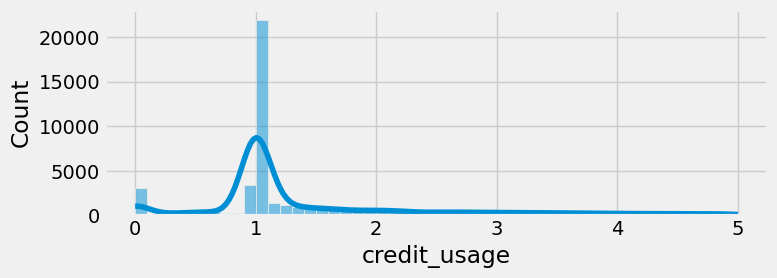

In [ ]:
bureau_df["credit_usage"] = (
    bureau_df["AMT_CREDIT_SUM"] / bureau_df["AMT_CREDIT_SUM_LIMIT"]
).replace(np.inf, np.nan)
plot_numeric_dist(bureau_df, "credit_usage", xlim=[0, 5])
metrics_dict["credit_usage"] = ["max", "median", "min", "sum"]

#### Closed Credit Duration

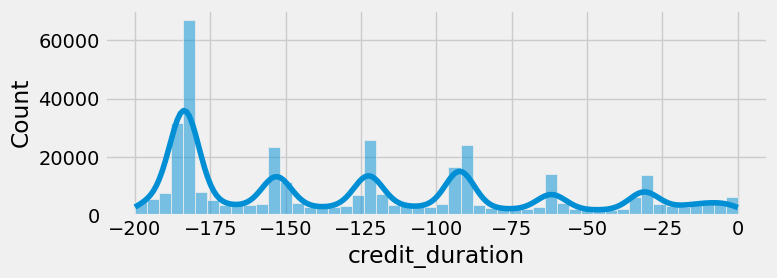

In [ ]:
bureau_df["credit_duration"] = (bureau_df["DAYS_CREDIT"] - bureau_df["DAYS_ENDDATE_FACT"])
plot_numeric_dist(bureau_df, "credit_duration", xlim=[-200, 0])
metrics_dict["credit_duration"] = ["max", "median", "min", "sum"]

### Credit type
We consider only active, closed and other credit, to not create too sparse rows.

In [ ]:
bureau_df = bureau_helper.simplify_credit_type(bureau_df)
metrics_dict["CREDIT_TYPE"] = "onehot_count"
bureau_df.head(3)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,credit_usage,credit_duration
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN,NaN,-344.0
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN,NaN,NaN


We can see that credit durations tend to fluctuate, but are usually handed out at month long intervals.

### Integration of bureau_balance
We load the aggregated dataframe from nb5 -its columns are then simplified to the most important ones.

In [ ]:
balance_df = joblib.load("data/processed/bureau_balance_aggregated.pkl")
balance_df = bureau_helper.process_bureau_balance(balance_df)
display(balance_df.head(5))

,SK_ID_BUREAU,bur_bal_f_1,bur_bal_f_0,bur_bal_bad_payments
0,5001709,C,C,0
1,5001710,C,C,0
2,5001711,0,0,0
3,5001712,C,C,0
4,5001713,X,X,0


It is then merged with the larger bureau_df

In [ ]:
bureau_df = pd.merge(
    bureau_df, balance_df, on="SK_ID_BUREAU", how="left"
)

display(bureau_df.head(3))
metrics_dict["bur_bal_bad_payments"] = ["sum", "mean", "max", "min"]
metrics_dict["bur_bal_f_0"] = ["onehot_count"]

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,credit_usage,credit_duration,bur_bal_f_1,bur_bal_f_0,bur_bal_bad_payments
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,NaN,0.0,Consumer credit,-131,NaN,NaN,-344.0,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,NaN,0.0,Credit card,-20,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,NaN,0.0,Consumer credit,-16,NaN,NaN,NaN,NaN,NaN,NaN


* Note, NA values are filled with 0, since people who did not take out loans cannot miss deadlines.

These columns are then similarly aggregated

In [ ]:
importlib.reload(aggregator_helper)
agg = aggregator_helper.RowAggregator(
    bureau_df, stack_columns=["SK_ID_CURR", "CREDIT_ACTIVE"], agg_dict=metrics_dict
)
agg_bureau = agg.get_df()
agg_bureau.head(3)

,SK_ID_CURR,count_CREDIT_ACTIVE_Active,count_CREDIT_ACTIVE_Closed,count_CREDIT_ACTIVE_Other,min_DAYS_CREDIT_Active,min_DAYS_CREDIT_Closed,min_DAYS_CREDIT_Other,median_DAYS_CREDIT_Active,median_DAYS_CREDIT_Closed,median_DAYS_CREDIT_Other,...,onehot_count_bur_bal_f_0_4_Other,onehot_count_bur_bal_f_0_5_Active,onehot_count_bur_bal_f_0_5_Closed,onehot_count_bur_bal_f_0_5_Other,onehot_count_bur_bal_f_0_C_Active,onehot_count_bur_bal_f_0_C_Closed,onehot_count_bur_bal_f_0_C_Other,onehot_count_bur_bal_f_0_X_Active,onehot_count_bur_bal_f_0_X_Closed,onehot_count_bur_bal_f_0_X_Other
0,100001,3.0,4.0,NaN,-559.0,-1572.0,NaN,-320.0,-894.0,NaN,...,0,0,0,0,0,4,0,1,0,0
1,100002,2.0,6.0,NaN,-1042.0,-1437.0,NaN,-572.5,-1082.0,NaN,...,0,0,0,0,0,1,0,0,0,0
2,100003,1.0,3.0,NaN,-606.0,-2586.0,NaN,-606.0,-1636.0,NaN,...,0,0,0,0,0,0,0,0,0,0


#### Model Test

The split columns were successfully introduced.

In [ ]:
X_train = app.merge(agg_bureau, on="SK_ID_CURR", how="left")
X_train.drop(columns=["SK_ID_CURR"], inplace=True)
y_train = X_train.pop("TARGET")

submissions.cv_lgbm(X_train, y_train)

,average_precision,roc_auc,f1_macro
mean,0.2524,0.7645,0.5488
std,0.0063,0.0042,0.0011


Although marginal, there is a performance increase from roc_auc of 0.7641.

# Conclusions

### Integrated workflow
The final aggregated bureau df is then saved for further use.
* Note that encoding target as int is required to support nan values (as opposed to bool)

In [ ]:
app_test = preprocessing.load_pkl_to_preprocessor('application_test')
base = pd.concat([app_test.data, app], ignore_index=True)
app_test.data = base
base = app_test.convert_all('category') 
base["TARGET"] = base["TARGET"].astype(float)

save_bureau = base.merge(agg_bureau, on="SK_ID_CURR", how="left")

save_bureau.info()

joblib.dump(save_bureau, "data/processed/aggregated_bureau.jbl")

Loading tables: ['application_test.csv']
loaded application_test with shape (48744, 121)
No missing columns.
Unexpected columns: ['SK_ID_CURR']
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'TARGET']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Columns: 374 entries, SK_ID_CURR to onehot_count_bur_bal_f_0_X_Other
dtypes: bool(34), category(14), float64(319), int64(6), object(1)
memory usage: 902.4+ MB


['data/processed/aggregated_bureau.jbl']

# submission

In [ ]:
X_test = app.merge(agg_bureau, on='SK_ID_CURR', how='left')
X_test.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 374 entries, SK_ID_CURR to onehot_count_bur_bal_f_0_X_Other
dtypes: bool(35), category(14), float64(318), int64(6), object(1)
memory usage: 776.9+ MB


In [ ]:
submissions.lgbm_submission(
    X_train, y_train, X_test, "bureau_aggregated_model"
)

Submission created: submissions\sub_2025-08-07_08-57_bureau_aggregated_model.csv


'submissions\\sub_2025-08-07_08-57_bureau_aggregated_model.csv'

Public score increase 0.75578 vs (0.743) was achieved.